## Read in the appropriate packages

In [259]:
#conda install -c conda-forge frozendict
#conda install -c conda-forge yfinance

In [260]:
from pandas_datareader import data as pdr #read data from yahoo finance api
import yfinance as yf
import matplotlib.pyplot as plt #viz #GUI manager
import seaborn as sns #viz #plotly is another package
import datetime
import pandas as pd
import numpy as np
from pandas import Grouper #groupby
#statistical data exploration, conducting statistical tests, and estimation of different statistical models
import statsmodels.api as sm
from statsmodels.graphics.tsaplots import plot_acf #autocorrelation plot
from statsmodels.tsa.api import SimpleExpSmoothing
from statsmodels.tsa.holtwinters import ExponentialSmoothing # double and triple exponential smoothing
from pandas.plotting import autocorrelation_plot #autocorrelation plot
from statsmodels.graphics.gofplots import qqplot #residual diagnostics
from sklearn.metrics import mean_squared_error #accuracy metrics
from math import sqrt
from sklearn.metrics import mean_absolute_error #accuracy metrics

from random import gauss #create gaussian white noise
from random import seed
from pandas import Series

# Part 1: Problem Definition and Economic Factors

**Target Stock:** Advanced Micro Devices, Inc. (AMD)

The three U.S. economic factors selected for this analysis are:

1. Consumer Price Index (CPI) / Inflation
2. Unemployment Rate
3. Federal Funds Rate

For this analysis, I selected Advanced Micro Devices, Inc. (AMD) as the target stock. AMD is a major semiconductor company whose performance is influenced not only by company-specific factors, such as product launches and competition, but also by broader economic conditions. I selected three U.S. economic factors—inflation, the unemployment rate, and the federal funds rate—to examine whether changes in the macroeconomic environment are associated with AMD’s stock price.

The first factor is inflation, measured using the Consumer Price Index for All Urban Consumers (CPIAUCSL). I convert the monthly CPI index into a year-over-year inflation rate. FRED notes that percentage changes in CPI measure inflation and that the year-over-year change is one of the most commonly used inflation measures. Inflation may influence AMD through several channels. Higher inflation can increase business costs and reduce consumers’ real purchasing power. It can also affect expectations about monetary policy and interest rates, which may influence technology-stock valuations.

The second factor is the U.S. unemployment rate. Unemployment provides an indicator of overall labor-market and economic conditions. Higher unemployment may signal weaker economic activity and lower consumer or business spending. This could affect demand for products that use AMD processors, including personal computers, gaming devices, and enterprise technology. The unemployment data are monthly and seasonally adjusted.

The third factor is the federal funds rate, which represents an important measure of U.S. monetary policy. Higher interest rates increase financing costs and also raise the discount rate applied to future corporate earnings. This may be particularly relevant for technology stocks whose valuations depend heavily on expectations of future growth. The monthly federal funds rate is published by the Federal Reserve and available through FRED.

Historical AMD stock-price data are obtained from Yahoo Finance, while all three economic indicators are collected from the Federal Reserve Economic Data (FRED) database.

### 1.1 Stock Selection and Study Period

AMD (Advanced Micro Devices, Inc.) is selected as the S&P 500 stock for this analysis. Historical daily stock price data are collected from Yahoo Finance for the selected study period.

In [261]:
# Define stock ticker and date range
stock_ticker = 'AMD'
stock_start_date = datetime.date(2010,1,1)
stock_end_date = datetime.date(2026, 9, 1)

# Fetch the stock price from Yahoo Finance using yfinance
stock_df = yf.download(stock_ticker, start=stock_start_date, end=stock_end_date)

/tmp/ipykernel_864/1305688405.py:7: FutureWarning: YF.download() has changed argument auto_adjust default to True
  stock_df = yf.download(stock_ticker, start=stock_start_date, end=stock_end_date)
[*********************100%***********************]  1 of 1 completed


In [262]:
stock_df

Price,Close,High,Low,Open,Volume
Ticker,AMD,AMD,AMD,AMD,AMD
Date,,,,,
2010-01-04,9.700000,9.900000,9.680000,9.790000,18748700
2010-01-05,9.710000,9.900000,9.680000,9.710000,22145700
2010-01-06,9.570000,9.760000,9.550000,9.680000,18643400
2010-01-07,9.470000,9.550000,9.180000,9.510000,26806800
2010-01-08,9.430000,9.470000,9.290000,9.370000,13752800
...,...,...,...,...,...
2026-08-25,479.179993,481.500000,469.070007,474.200012,19001400
2026-08-26,480.929993,491.119995,474.579987,475.070007,14348100


In [263]:
stock_df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 4190 entries, 2010-01-04 to 2026-08-31
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   (Close, AMD)   4190 non-null   float64
 1   (High, AMD)    4190 non-null   float64
 2   (Low, AMD)     4190 non-null   float64
 3   (Open, AMD)    4190 non-null   float64
 4   (Volume, AMD)  4190 non-null   int64  
dtypes: float64(4), int64(1)
memory usage: 196.4 KB


In [264]:
stock_df.index

DatetimeIndex(['2010-01-04', '2010-01-05', '2010-01-06', '2010-01-07',
               '2010-01-08', '2010-01-11', '2010-01-12', '2010-01-13',
               '2010-01-14', '2010-01-15',
               ...
               '2026-08-18', '2026-08-19', '2026-08-20', '2026-08-21',
               '2026-08-24', '2026-08-25', '2026-08-26', '2026-08-27',
               '2026-08-28', '2026-08-31'],
              dtype='datetime64[ns]', name='Date', length=4190, freq=None)

### 1.2 Economic Factors and Data Sources

Three U.S. economic factors are included in the analysis:

1. Inflation Rate
2. Unemployment Rate
3. Federal Funds Rate

The economic data are collected from the Federal Reserve Economic Data (FRED) database. These variables are selected because they represent changes in the general price level, labor market conditions, and monetary policy, all of which may influence stock market performance.

In [265]:
# Define economic indicators from FRED
economic_factors = ['CPIAUCSL', 'UNRATE', 'FEDFUNDS']

economic_df = pdr.DataReader(
    economic_factors,
    'fred',
    stock_start_date,
    stock_end_date
)

economic_df.head()

,CPIAUCSL,UNRATE,FEDFUNDS
DATE,,,
2010-01-01,217.488,9.8,0.11
2010-02-01,217.281,9.8,0.13
2010-03-01,217.353,9.9,0.16
2010-04-01,217.403,9.9,0.20
2010-05-01,217.290,9.6,0.20


In [266]:
economic_df = economic_df.rename(columns={
    'CPIAUCSL': 'CPI',
    'UNRATE': 'Unemployment_Rate',
    'FEDFUNDS': 'Federal_Funds_Rate'
})

economic_df['Inflation_Rate'] = (
    economic_df['CPI'].pct_change(12, fill_method=None) * 100
)

economic_df.head(15)

,CPI,Unemployment_Rate,Federal_Funds_Rate,Inflation_Rate
DATE,,,,
2010-01-01,217.488,9.8,0.11,NaN
2010-02-01,217.281,9.8,0.13,NaN
2010-03-01,217.353,9.9,0.16,NaN
2010-04-01,217.403,9.9,0.20,NaN
2010-05-01,217.290,9.6,0.20,NaN
2010-06-01,217.199,9.4,0.18,NaN
2010-07-01,217.605,9.4,0.18,NaN
2010-08-01,217.923,9.5,0.19,NaN
2010-09-01,218.275,9.5,0.19,NaN


In [267]:
economic_df = economic_df[
    ['Inflation_Rate', 'Unemployment_Rate', 'Federal_Funds_Rate']
]

economic_df.head(15)

,Inflation_Rate,Unemployment_Rate,Federal_Funds_Rate
DATE,,,
2010-01-01,NaN,9.8,0.11
2010-02-01,NaN,9.8,0.13
2010-03-01,NaN,9.9,0.16
2010-04-01,NaN,9.9,0.20
2010-05-01,NaN,9.6,0.20
2010-06-01,NaN,9.4,0.18
2010-07-01,NaN,9.4,0.18
2010-08-01,NaN,9.5,0.19
2010-09-01,NaN,9.5,0.19


In [268]:
economic_df.info()
economic_df.describe()
economic_df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 200 entries, 2010-01-01 to 2026-08-01
Freq: MS
Data columns (total 3 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Inflation_Rate      186 non-null    float64
 1   Unemployment_Rate   199 non-null    float64
 2   Federal_Funds_Rate  200 non-null    float64
dtypes: float64(3)
memory usage: 6.2 KB


,0
Inflation_Rate,14
Unemployment_Rate,1
Federal_Funds_Rate,0


### 1.3 Constructing Median Monthly AMD Stock Price

The original AMD dataset contains daily stock prices. Since the assignment focuses on the median monthly stock price, daily closing prices are grouped by month and the median closing price is calculated for each month.

In [269]:
amd_daily = stock_df[['Close']].copy()
amd_daily.columns = ['AMD_Price']

In [270]:
# Convert daily AMD prices to monthly median prices
amd_monthly = amd_daily.groupby(pd.Grouper(freq='MS')).median()

amd_monthly.head()

,AMD_Price
Date,
2010-01-01,8.990
2010-02-01,7.890
2010-03-01,9.020
2010-04-01,9.580
2010-05-01,8.575


In [271]:
# Combine AMD monthly prices with U.S. economic factors
analysis_df = amd_monthly.join(economic_df, how='inner')
analysis_df = analysis_df.dropna()

analysis_df.head(15)

,AMD_Price,Inflation_Rate,Unemployment_Rate,Federal_Funds_Rate
Date,,,,
2011-01-01,8.150,1.700783,9.1,0.17
2011-02-01,8.550,2.124898,9.0,0.16
2011-03-01,8.670,2.619242,9.0,0.14
2011-04-01,8.415,3.077234,9.1,0.10
2011-05-01,8.680,3.458972,9.0,0.09
2011-06-01,7.360,3.502318,9.1,0.09
2011-07-01,6.975,3.579881,9.0,0.07
2011-08-01,6.370,3.754996,9.0,0.10
2011-09-01,6.520,3.812622,9.0,0.08


In [272]:
analysis_df.info()
analysis_df.describe()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 186 entries, 2011-01-01 to 2026-07-01
Data columns (total 4 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   AMD_Price           186 non-null    float64
 1   Inflation_Rate      186 non-null    float64
 2   Unemployment_Rate   186 non-null    float64
 3   Federal_Funds_Rate  186 non-null    float64
dtypes: float64(4)
memory usage: 7.3 KB


,AMD_Price,Inflation_Rate,Unemployment_Rate,Federal_Funds_Rate
count,186.000000,186.000000,186.000000,186.000000
mean,60.521371,2.675603,5.403226,1.564946
std,82.748465,1.916693,1.993311,1.850117
min,1.810000,-0.229931,3.400000,0.050000
25%,4.677500,1.570705,3.900000,0.100000
50%,20.000000,2.222017,4.500000,0.400000
75%,94.559998,3.151142,6.675000,2.417500
max,519.885010,8.979361,14.800000,5.330000


# Part 2: Exploratory Data Analysis (EDA)

This section examines the relationship between AMD's median monthly stock price and the three selected U.S. economic factors: inflation, unemployment, and the Federal Funds Rate. Visualizations, correlation analysis, differencing, and lagged relationships are used to assess whether these variables may provide useful information for explaining changes in AMD stock prices.

### 2.1 Visual Inspection of AMD Stock Price

The monthly median AMD stock price is plotted over time to examine its overall pattern, including long-term trends and changes in volatility. A visual inspection provides an initial understanding of the time-series behavior before analyzing its relationship with the economic variables.

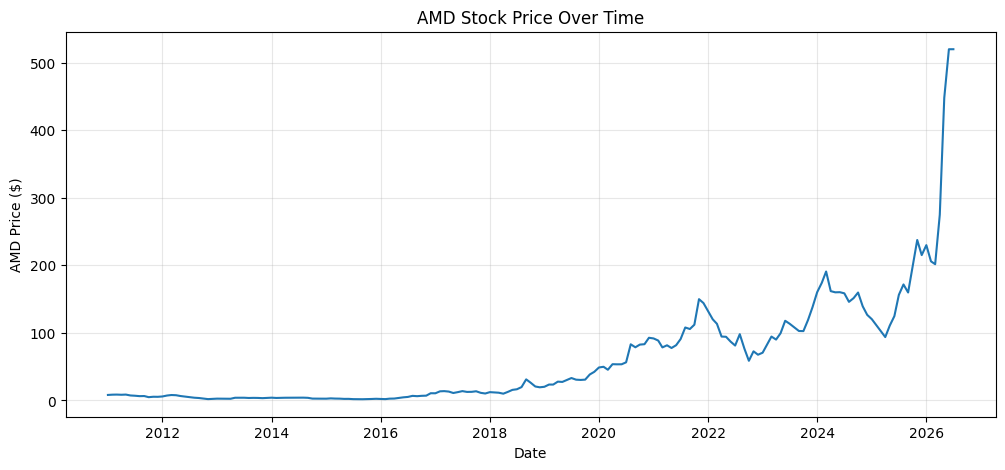

In [273]:
# AMD Stock Price Over Time
plt.figure(figsize=(12, 5))

plt.plot(
    analysis_df.index,
    analysis_df['AMD_Price']
)

plt.title('AMD Stock Price Over Time')
plt.xlabel('Date')
plt.ylabel('AMD Price ($)')
plt.grid(alpha=0.3)

plt.show()

The raw price plot may make volatility appear larger in later periods simply because the stock price itself is much higher. A logarithmic scale helps evaluate changes in the series in relative rather than absolute terms.

This plot is used as a descriptive diagnostic of the AMD price series rather than as direct evidence about the predictive ability of the macroeconomic variables.

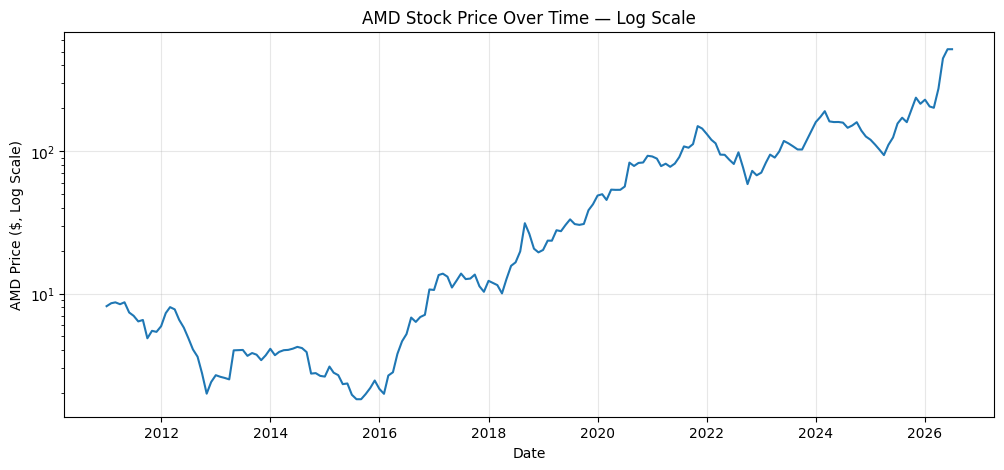

In [274]:
# AMD Stock Price on a Logarithmic Scale
plt.figure(figsize=(12, 5))

plt.plot(
    analysis_df.index,
    analysis_df['AMD_Price']
)

plt.yscale('log')

plt.title('AMD Stock Price Over Time — Log Scale')
plt.xlabel('Date')
plt.ylabel('AMD Price ($, Log Scale)')
plt.grid(alpha=0.3)

plt.show()

The AMD price series shows a clear long-term trend, with substantially higher price levels in the later part of the sample. The magnitude of price fluctuations also appears larger when the stock price is higher.

However, the log-scale plot suggests that some of the apparent increase in volatility may be related to the higher overall price level. Therefore, the raw price plot alone is not sufficient to conclude that AMD's relative volatility has continuously increased.

Most importantly for the predictor analysis, the strong trend in AMD's price suggests that relationships measured using raw price levels should be interpreted cautiously. Trending time-series variables can exhibit high correlations even when their underlying economic relationship is weak.

### 2.2 Autocorrelation of AMD Stock Price

The autocorrelation function (ACF) is used to examine whether the current AMD stock price is correlated with its own past values. Strong autocorrelation in the raw price series may indicate persistence or trend, which is important to consider when interpreting correlations with other trending economic variables.

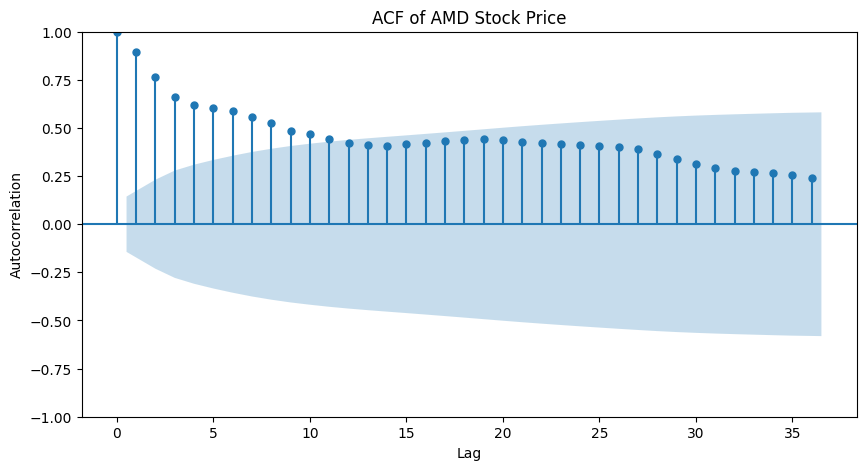

In [275]:
# Autocorrelation of AMD Stock Price
fig, ax = plt.subplots(figsize=(10, 5))

plot_acf(
    analysis_df['AMD_Price'].dropna(),
    lags=36,
    ax=ax
)

ax.set_title('ACF of AMD Stock Price')
ax.set_xlabel('Lag')
ax.set_ylabel('Autocorrelation')

plt.show()

The raw AMD stock price exhibits strong positive autocorrelation, particularly at the first several lags. The autocorrelation is approximately 0.9 at lag 1 and declines gradually as the lag increases rather than quickly approaching zero.

This pattern indicates substantial persistence in the AMD price series: current price levels are strongly related to recent historical price levels. The gradual decay in autocorrelation also suggests that the raw price series contains strong time dependence and may be non-stationary.

Therefore, observations in the raw AMD price series should not be treated as independent. This is important for the subsequent macroeconomic analysis because correlations between trending or highly persistent time series may be inflated by common time trends rather than reflecting meaningful economic relationships.

# 2.3 Raw Relationships Between AMD Price and Macroeconomic Factors

After examining the time dependence of AMD's stock price, I next explore its contemporaneous relationships with three macroeconomic variables: inflation, unemployment, and the federal funds rate.

Scatter plots are used to visually examine the direction, strength, and shape of these relationships. At this stage, the analysis uses the raw variables and is descriptive only. Because the AMD price series exhibits strong persistence and long-term trend, any apparent relationships should be interpreted cautiously.

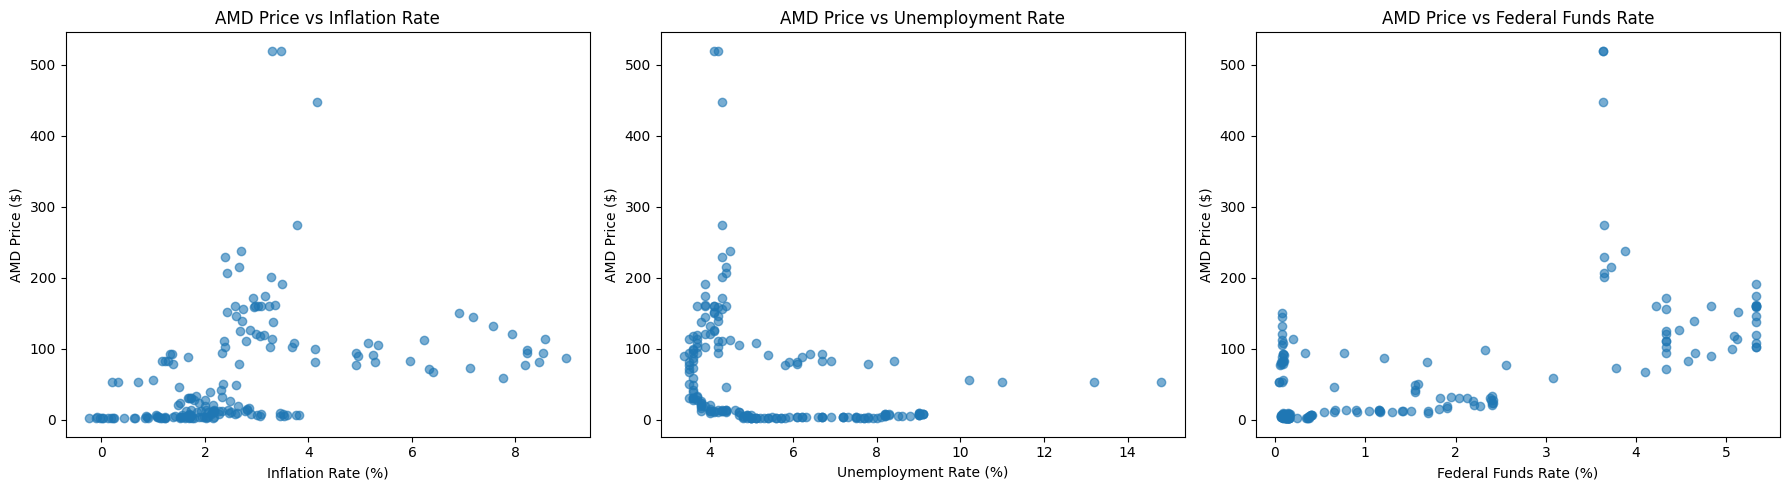

In [276]:
# Scatter Plots of AMD Price and Macroeconomic Variables
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# AMD vs Inflation Rate
axes[0].scatter(
    analysis_df['Inflation_Rate'],
    analysis_df['AMD_Price'],
    alpha=0.6
)
axes[0].set_title('AMD Price vs Inflation Rate')
axes[0].set_xlabel('Inflation Rate (%)')
axes[0].set_ylabel('AMD Price ($)')


# AMD vs Unemployment Rate
axes[1].scatter(
    analysis_df['Unemployment_Rate'],
    analysis_df['AMD_Price'],
    alpha=0.6
)
axes[1].set_title('AMD Price vs Unemployment Rate')
axes[1].set_xlabel('Unemployment Rate (%)')
axes[1].set_ylabel('AMD Price ($)')


# AMD vs Federal Funds Rate
axes[2].scatter(
    analysis_df['Federal_Funds_Rate'],
    analysis_df['AMD_Price'],
    alpha=0.6
)
axes[2].set_title('AMD Price vs Federal Funds Rate')
axes[2].set_xlabel('Federal Funds Rate (%)')
axes[2].set_ylabel('AMD Price ($)')


plt.tight_layout()
plt.show()


The scatter plots do not suggest simple linear relationships between AMD's stock price and the three macroeconomic variables.

AMD's highest price observations are concentrated around moderate inflation rates, relatively low unemployment rates, and federal funds rates near 3.6%. The unemployment plot shows some visual evidence of a negative association, while the relationships with inflation and the federal funds rate appear more clustered and potentially nonlinear.

A review of the highest AMD price observations shows that these values occur primarily in consecutive recent months rather than as isolated observations. This suggests that some of the clustering in the scatter plots may reflect different historical periods and the strong time trend in AMD's price.

Therefore, the raw relationships should be interpreted cautiously before drawing conclusions about predictive ability.

### 2.4 Raw Correlation Analysis

To quantify the relationships observed in the scatter plots, I calculate the Pearson correlation coefficients between AMD's stock price and the three macroeconomic variables.

The Pearson correlation coefficient measures the direction and strength of a linear relationship between two variables, ranging from -1 to 1. These correlations describe contemporaneous relationships in the raw data and should not yet be interpreted as evidence of predictive ability.

In [277]:
raw_corr = analysis_df[
    [
        'AMD_Price',
        'Inflation_Rate',
        'Unemployment_Rate',
        'Federal_Funds_Rate'
    ]
].corr()

raw_corr

,AMD_Price,Inflation_Rate,Unemployment_Rate,Federal_Funds_Rate
AMD_Price,1.000000,0.369216,-0.328945,0.602721
Inflation_Rate,0.369216,1.000000,-0.336983,0.256983
Unemployment_Rate,-0.328945,-0.336983,1.000000,-0.581402
Federal_Funds_Rate,0.602721,0.256983,-0.581402,1.000000


In [278]:
amd_raw_corr = (
    raw_corr['AMD_Price']
    .drop('AMD_Price')
    .sort_values(key=abs, ascending=False)
)

amd_raw_corr

,AMD_Price
Federal_Funds_Rate,0.602721
Inflation_Rate,0.369216
Unemployment_Rate,-0.328945


Among the three macroeconomic variables, the federal funds rate has the strongest raw correlation with AMD's stock price, with a Pearson correlation of approximately 0.59. Inflation has a weaker positive correlation of approximately 0.35, while unemployment has a negative correlation of approximately -0.32.

At face value, these results suggest that AMD prices tend to be higher when the federal funds rate and inflation are higher, and lower when unemployment is higher.

However, these correlations should not be interpreted as evidence that the macroeconomic variables are strong predictors of AMD's stock price. The earlier ACF analysis showed substantial persistence in the AMD price series, and the scatter plots also indicated that observations from similar historical periods tend to cluster together. Therefore, part of the raw correlation may reflect common time patterns rather than stable economic relationships.

### 2.5 Spurious Correlation and Differencing

The raw correlation analysis may be affected by spurious correlation. In time-series data, two variables can appear to be strongly correlated simply because they evolve systematically over time, even when there is no stable economic relationship between them.

This concern is especially relevant for AMD's raw stock price because the series exhibits a strong long-term trend and substantial autocorrelation.

The differenced series measures how much AMD's stock price changes from one month to the next rather than comparing the absolute price level across different historical periods.

In [279]:
analysis_df['AMD_Price_Change'] = (
    analysis_df['AMD_Price'].diff()
)

analysis_df[
    ['AMD_Price', 'AMD_Price_Change']
].head()

,AMD_Price,AMD_Price_Change
Date,,
2011-01-01,8.150,NaN
2011-02-01,8.550,0.400
2011-03-01,8.670,0.120
2011-04-01,8.415,-0.255
2011-05-01,8.680,0.265


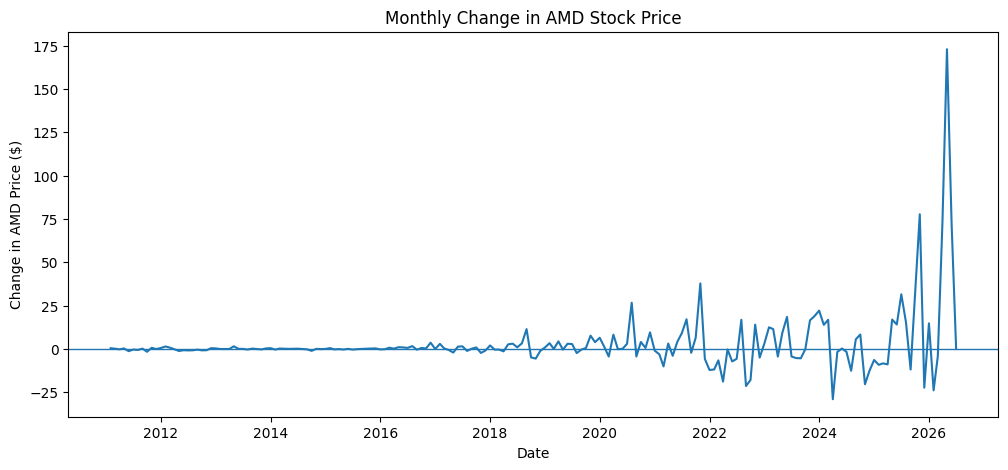

In [280]:
# AMD Price Changes Over Time
plt.figure(figsize=(12, 5))

plt.plot(
    analysis_df.index,
    analysis_df['AMD_Price_Change']
)

plt.axhline(0, linewidth=1)

plt.title('Monthly Change in AMD Stock Price')
plt.xlabel('Date')
plt.ylabel('Change in AMD Price ($)')

plt.show()

### 2.6 Autocorrelation After Differencing

To determine whether first differencing reduces the strong persistence observed in the raw AMD price series, I examine the autocorrelation function of the monthly price changes.

If the autocorrelations become substantially smaller after differencing, this would suggest that much of the persistence in the original price series was associated with its price level and long-term trend.

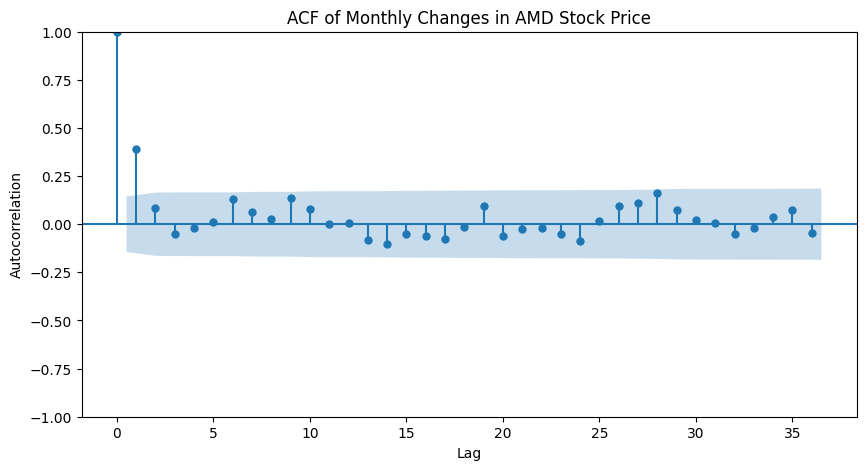

In [281]:
fig, ax = plt.subplots(figsize=(10, 5))

plot_acf(
    analysis_df['AMD_Price_Change'].dropna(),
    lags=36,
    ax=ax
)

ax.set_title('ACF of Monthly Changes in AMD Stock Price')
ax.set_xlabel('Lag')
ax.set_ylabel('Autocorrelation')

plt.show()

First differencing substantially reduces the strong autocorrelation observed in the raw AMD price series. In the raw price series, autocorrelation was very high at the first several lags and declined gradually. After differencing, most autocorrelations are much closer to zero and fall within the confidence interval.

This suggests that a large portion of the persistence in the original series was associated with the stock price level and its long-term trend.

However, the lag-1 autocorrelation remains noticeably positive and outside the confidence interval, indicating that some short-term serial dependence remains in AMD's monthly price changes. Therefore, differencing substantially reduces, but does not completely eliminate, autocorrelation.

### 2.7 Assessment of Economic Factors as Predictors

Before re-evaluating the relationships between AMD and the macroeconomic variables, I examine the time-series behavior of inflation, unemployment, and the federal funds rate.

Although these variables are already expressed as rates rather than price levels, they may still exhibit persistence or changing levels over time. Time-series plots and autocorrelation functions are therefore used to determine whether additional transformation is appropriate.

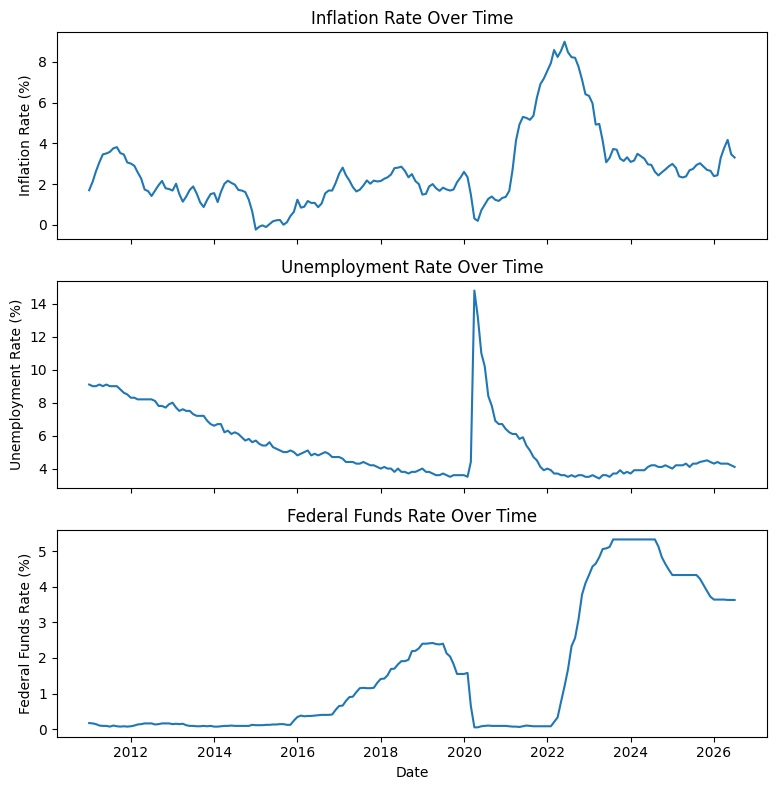

In [282]:
fig, axes = plt.subplots(3, 1, figsize=(8, 8), sharex=True)

# Inflation Rate
axes[0].plot(
    analysis_df.index,
    analysis_df['Inflation_Rate']
)
axes[0].set_title('Inflation Rate Over Time')
axes[0].set_ylabel('Inflation Rate (%)')


# Unemployment Rate
axes[1].plot(
    analysis_df.index,
    analysis_df['Unemployment_Rate']
)
axes[1].set_title('Unemployment Rate Over Time')
axes[1].set_ylabel('Unemployment Rate (%)')


# Federal Funds Rate
axes[2].plot(
    analysis_df.index,
    analysis_df['Federal_Funds_Rate']
)
axes[2].set_title('Federal Funds Rate Over Time')
axes[2].set_ylabel('Federal Funds Rate (%)')
axes[2].set_xlabel('Date')


plt.tight_layout()
plt.show()

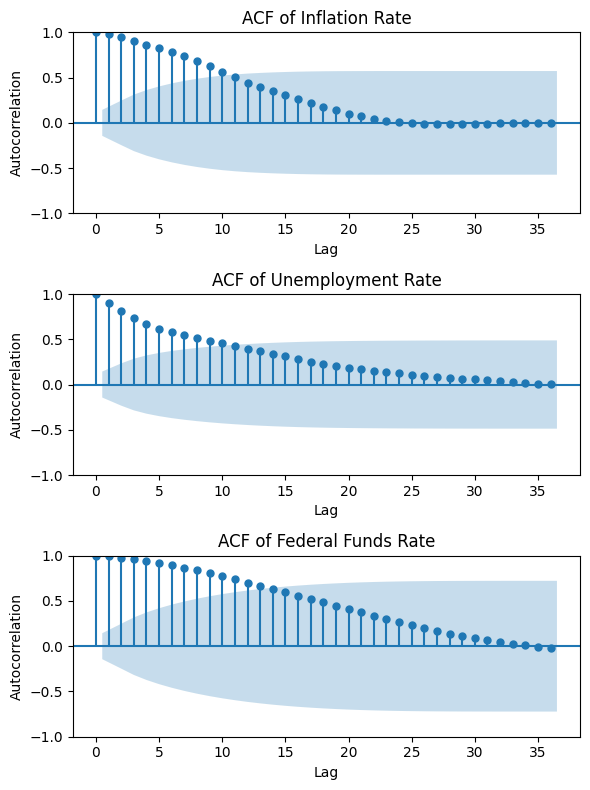

In [283]:
# Autocorrelation of Macroeconomic Variables
fig, axes = plt.subplots(3, 1, figsize=(6, 8))

plot_acf(
    analysis_df['Inflation_Rate'].dropna(),
    lags=36,
    ax=axes[0]
)
axes[0].set_title('ACF of Inflation Rate')
axes[0].set_xlabel('Lag')
axes[0].set_ylabel('Autocorrelation')


plot_acf(
    analysis_df['Unemployment_Rate'].dropna(),
    lags=36,
    ax=axes[1]
)
axes[1].set_title('ACF of Unemployment Rate')
axes[1].set_xlabel('Lag')
axes[1].set_ylabel('Autocorrelation')


plot_acf(
    analysis_df['Federal_Funds_Rate'].dropna(),
    lags=36,
    ax=axes[2]
)
axes[2].set_title('ACF of Federal Funds Rate')
axes[2].set_xlabel('Lag')
axes[2].set_ylabel('Autocorrelation')


plt.tight_layout()
plt.show()

The three macroeconomic variables all exhibit substantial time dependence.

Inflation shows persistent periods of rising and falling price growth, including the pronounced inflationary episode in the early 2020s. Its autocorrelation remains high over multiple lags and declines gradually.

The unemployment rate also exhibits strong persistence. In addition to a long-term decline before 2020, the series contains a large temporary increase around 2020 followed by a gradual return toward lower levels.

The federal funds rate shows particularly clear policy regimes, including extended periods of near-zero rates, subsequent monetary tightening, and later rate reductions. Its ACF remains strongly positive across many lags.

Overall, the slowly declining autocorrelation functions indicate that all three macroeconomic series contain substantial persistence. Therefore, comparing AMD's monthly price changes directly with the raw levels of these macroeconomic variables may still mix short-term relationships with longer-run economic regimes.

### 2.8 Differencing the Macroeconomic Variables

Because inflation, unemployment, and the federal funds rate all exhibit substantial persistence, I also calculate their month-to-month changes.

This transformation shifts the analysis from comparing economic levels across different historical periods to examining whether short-term changes in economic conditions are associated with short-term changes in AMD's stock price.

In [284]:
analysis_df['Inflation_Change'] = (
    analysis_df['Inflation_Rate'].diff()
)

analysis_df['Unemployment_Change'] = (
    analysis_df['Unemployment_Rate'].diff()
)

analysis_df['Federal_Funds_Change'] = (
    analysis_df['Federal_Funds_Rate'].diff()
)

analysis_df[
    [
        'AMD_Price_Change',
        'Inflation_Change',
        'Unemployment_Change',
        'Federal_Funds_Change'
    ]
].head(10)

,AMD_Price_Change,Inflation_Change,Unemployment_Change,Federal_Funds_Change
Date,,,,
2011-01-01,NaN,NaN,NaN,NaN
2011-02-01,0.400,0.424115,-0.1,-0.01
2011-03-01,0.120,0.494343,0.0,-0.02
2011-04-01,-0.255,0.457993,0.1,-0.04
2011-05-01,0.265,0.381737,-0.1,-0.01
2011-06-01,-1.320,0.043346,0.1,0.00
2011-07-01,-0.385,0.077563,-0.1,-0.02
2011-08-01,-0.605,0.175115,0.0,0.03
2011-09-01,0.150,0.057626,0.0,-0.02


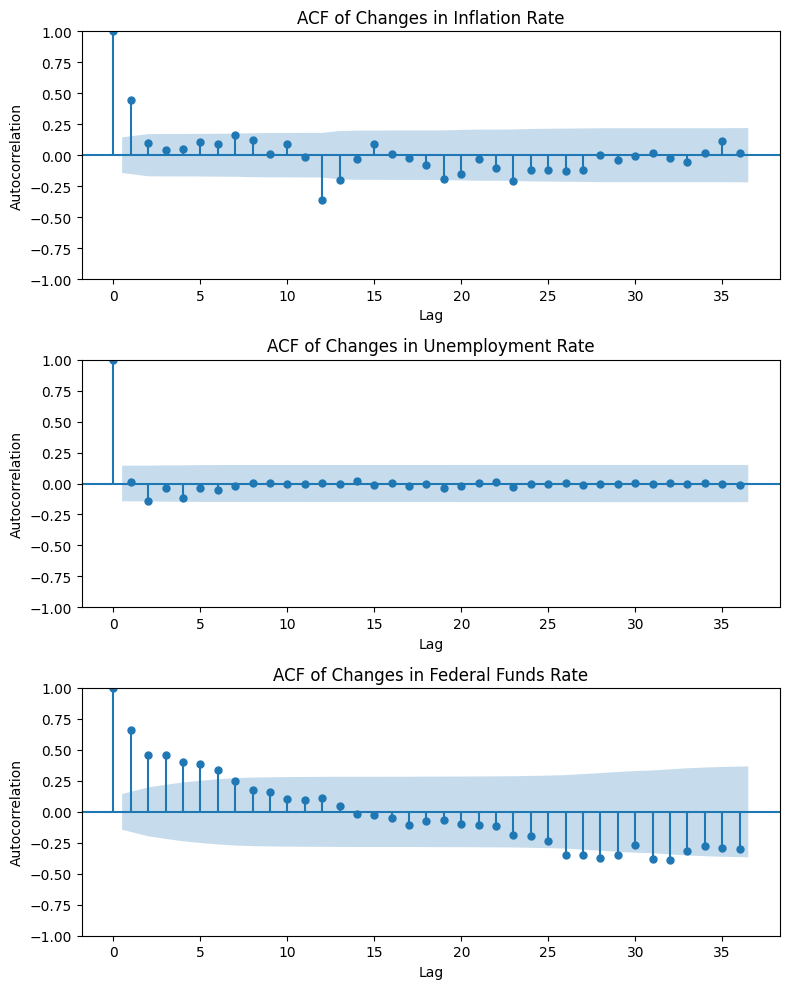

In [285]:
# Autocorrelation After Differencing
fig, axes = plt.subplots(3, 1, figsize=(8, 10))

plot_acf(
    analysis_df['Inflation_Change'].dropna(),
    lags=36,
    ax=axes[0]
)
axes[0].set_title('ACF of Changes in Inflation Rate')
axes[0].set_xlabel('Lag')
axes[0].set_ylabel('Autocorrelation')


plot_acf(
    analysis_df['Unemployment_Change'].dropna(),
    lags=36,
    ax=axes[1]
)
axes[1].set_title('ACF of Changes in Unemployment Rate')
axes[1].set_xlabel('Lag')
axes[1].set_ylabel('Autocorrelation')


plot_acf(
    analysis_df['Federal_Funds_Change'].dropna(),
    lags=36,
    ax=axes[2]
)
axes[2].set_title('ACF of Changes in Federal Funds Rate')
axes[2].set_xlabel('Lag')
axes[2].set_ylabel('Autocorrelation')

plt.tight_layout()
plt.show()

First differencing substantially reduces the persistence observed in the three macroeconomic rate series, although the effect differs across variables.

For inflation, most autocorrelations become much smaller after differencing, although a noticeable positive lag-1 autocorrelation remains. This suggests that month-to-month changes in inflation retain some short-term persistence.

The unemployment rate shows the largest reduction in serial dependence. After differencing, most autocorrelations are close to zero and fall within the confidence interval, indicating that much of the persistence in the raw unemployment rate was associated with its level.

Changes in the federal funds rate remain more strongly autocorrelated. This is economically plausible because monetary policy adjustments often occur in sustained tightening or easing cycles rather than as independent monthly changes.

Overall, first differencing substantially reduces the long-run persistence in the macroeconomic variables, although it does not completely eliminate serial dependence, particularly for the federal funds rate.

### 2.9 Relationships After Differencing

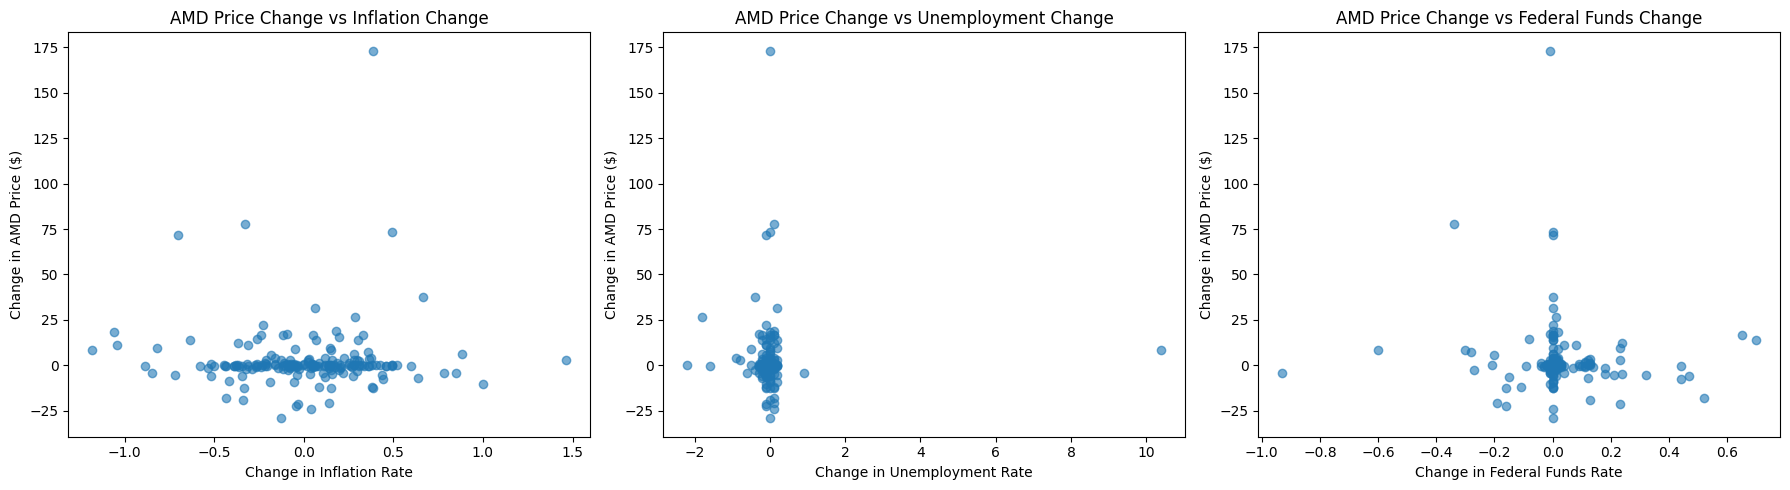

In [286]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# AMD Change vs Inflation Change
axes[0].scatter(
    analysis_df['Inflation_Change'],
    analysis_df['AMD_Price_Change'],
    alpha=0.6
)
axes[0].set_title('AMD Price Change vs Inflation Change')
axes[0].set_xlabel('Change in Inflation Rate')
axes[0].set_ylabel('Change in AMD Price ($)')


# AMD Change vs Unemployment Change
axes[1].scatter(
    analysis_df['Unemployment_Change'],
    analysis_df['AMD_Price_Change'],
    alpha=0.6
)
axes[1].set_title('AMD Price Change vs Unemployment Change')
axes[1].set_xlabel('Change in Unemployment Rate')
axes[1].set_ylabel('Change in AMD Price ($)')


# AMD Change vs Federal Funds Change
axes[2].scatter(
    analysis_df['Federal_Funds_Change'],
    analysis_df['AMD_Price_Change'],
    alpha=0.6
)
axes[2].set_title('AMD Price Change vs Federal Funds Change')
axes[2].set_xlabel('Change in Federal Funds Rate')
axes[2].set_ylabel('Change in AMD Price ($)')


plt.tight_layout()
plt.show()

In [287]:
diff_corr = analysis_df[
    [
        'AMD_Price_Change',
        'Inflation_Change',
        'Unemployment_Change',
        'Federal_Funds_Change'
    ]
].corr()

diff_corr

,AMD_Price_Change,Inflation_Change,Unemployment_Change,Federal_Funds_Change
AMD_Price_Change,1.000000,0.007719,0.009986,-0.063370
Inflation_Change,0.007719,1.000000,-0.286889,0.018877
Unemployment_Change,0.009986,-0.286889,1.000000,-0.306456
Federal_Funds_Change,-0.063370,0.018877,-0.306456,1.000000


The relationships change substantially after first differencing.

The correlation between AMD price changes and changes in inflation is approximately 0.02, while the correlation with changes in unemployment is approximately 0.01. Both values are very close to zero, indicating little contemporaneous linear relationship.

The most notable change occurs for the federal funds rate. Its raw correlation with AMD's price was approximately 0.59, but the correlation between monthly changes falls to approximately -0.06 after differencing.

Overall, all three correlations become close to zero after removing much of the persistence in the original series. This suggests that the relationships observed in the raw level data were likely influenced substantially by persistent levels, historical regimes, or common time patterns rather than stable short-term economic relationships.

Therefore, none of the three macroeconomic variables appears to have a strong contemporaneous linear relationship with monthly changes in AMD's stock price.

### 2.10 Lagged Relationships Between Macroeconomic Changes and AMD Price Changes

The contemporaneous correlations after differencing are close to zero. However, an economic variable may affect or precede stock-price movements with a delay rather than within the same month.

In [288]:
lags = range(0, 13)

inflation_lag_corr = []
unemployment_lag_corr = []
fed_lag_corr = []

for lag in lags:

    inflation_lag_corr.append(
        analysis_df['AMD_Price_Change'].corr(
            analysis_df['Inflation_Change'].shift(lag)
        )
    )

    unemployment_lag_corr.append(
        analysis_df['AMD_Price_Change'].corr(
            analysis_df['Unemployment_Change'].shift(lag)
        )
    )

    fed_lag_corr.append(
        analysis_df['AMD_Price_Change'].corr(
            analysis_df['Federal_Funds_Change'].shift(lag)
        )
    )

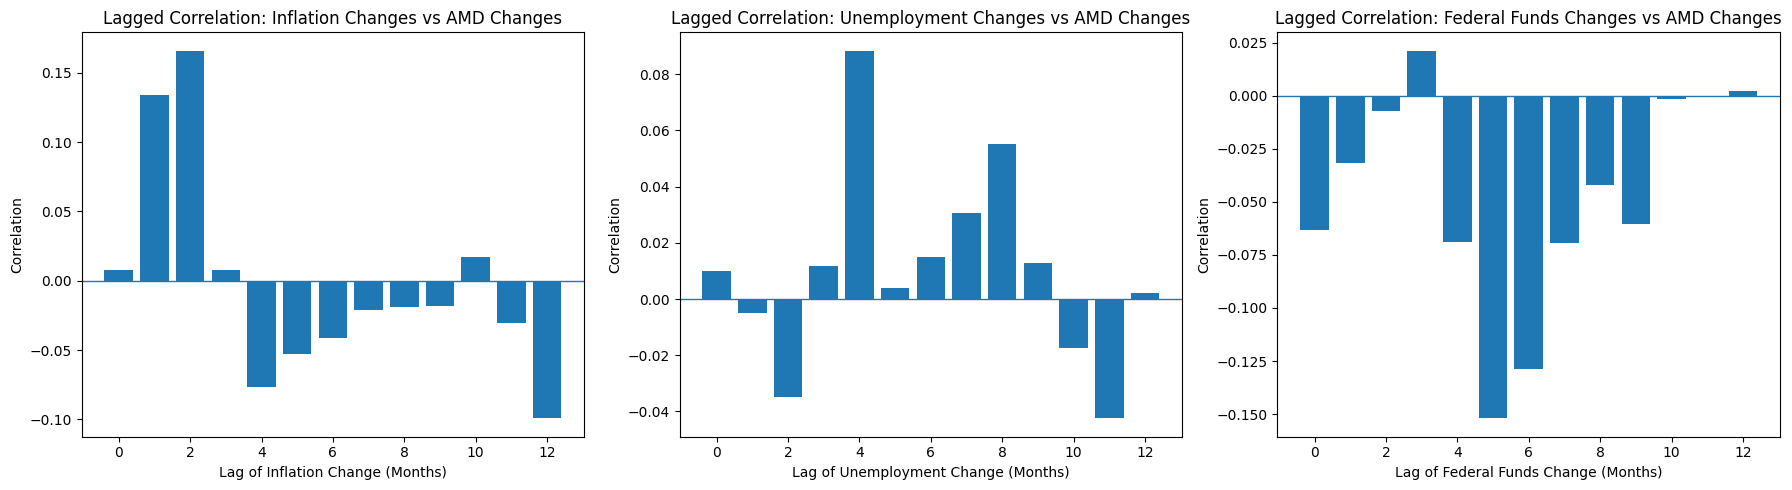

In [289]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Inflation
axes[0].bar(lags, inflation_lag_corr)
axes[0].axhline(0, linewidth=1)
axes[0].set_title('Lagged Correlation: Inflation Changes vs AMD Changes')
axes[0].set_xlabel('Lag of Inflation Change (Months)')
axes[0].set_ylabel('Correlation')


# Unemployment
axes[1].bar(lags, unemployment_lag_corr)
axes[1].axhline(0, linewidth=1)
axes[1].set_title('Lagged Correlation: Unemployment Changes vs AMD Changes')
axes[1].set_xlabel('Lag of Unemployment Change (Months)')
axes[1].set_ylabel('Correlation')


# Federal Funds
axes[2].bar(lags, fed_lag_corr)
axes[2].axhline(0, linewidth=1)
axes[2].set_title('Lagged Correlation: Federal Funds Changes vs AMD Changes')
axes[2].set_xlabel('Lag of Federal Funds Change (Months)')
axes[2].set_ylabel('Correlation')

plt.tight_layout()
plt.show()

In [290]:
lag_corr_df = pd.DataFrame({
    'Lag_Months': list(lags),
    'Inflation': inflation_lag_corr,
    'Unemployment': unemployment_lag_corr,
    'Federal_Funds': fed_lag_corr
})

lag_corr_df

,Lag_Months,Inflation,Unemployment,Federal_Funds
0,0,0.007719,0.009986,-0.063370
1,1,0.134121,-0.004836,-0.031632
2,2,0.165888,-0.034709,-0.007266
3,3,0.007793,0.011843,0.021155
4,4,-0.076657,0.088359,-0.068893
5,5,-0.052483,0.003772,-0.151975
6,6,-0.040997,0.015130,-0.128953
7,7,-0.020853,0.030680,-0.069616
8,8,-0.018714,0.055250,-0.042128
9,9,-0.018417,0.012821,-0.060549


The lagged correlations remain generally weak across all three macroeconomic variables.

Inflation shows its largest positive correlation at a lag of two months, approximately 0.19. This suggests a modest association between inflation changes two months earlier and current AMD price changes, but the relationship weakens quickly at longer lags.

Changes in unemployment show very little lagged association with AMD price changes. The largest correlation is less than 0.10, providing little evidence of a meaningful lagged linear relationship.

Changes in the federal funds rate show a modest negative relationship around lags five and six, with correlations of approximately -0.15 and -0.13, respectively. However, these relationships are still relatively weak and are not consistently observed across the full range of lags.

Overall, the lagged analysis does not reveal a strong or stable linear relationship between past changes in the three macroeconomic variables and current AMD price changes.

### 2.11 Predictor Assessment

The analysis produces substantially different conclusions depending on whether the raw levels or month-to-month changes are examined.

Using raw levels, AMD's stock price appears moderately correlated with the federal funds rate (approximately 0.60), inflation (approximately 0.37), and unemployment (approximately -0.33). However, the ACF analysis shows that AMD's raw price and all three macroeconomic variables exhibit substantial persistence over time.

After first differencing, most of this persistence is reduced, and the contemporaneous correlations with AMD price changes fall close to zero:

* Inflation change: approximately 0.01
* Unemployment change: approximately 0.01
* Federal funds rate change: approximately -0.06

The lagged analysis from 0 to 12 months also fails to identify a strong and stable relationship. Inflation shows its largest positive correlation at a two-month lag, approximately 0.17, while federal funds rate changes show modest negative correlations around five to six months, approximately -0.15 and -0.13. Changes in unemployment show very little lagged association with AMD price changes.

Therefore, the relatively large correlations observed in the raw level data appear to be influenced substantially by persistence and common historical patterns. Based on the differenced and lagged results, none of the three macroeconomic variables appears to be a strong standalone linear predictor of monthly AMD price changes.


## Part 3: Univariate Forecasting of AMD Stock Price

This section develops univariate forecasts of AMD's monthly stock price using exponential smoothing methods. Only the historical AMD price series is used; the macroeconomic variables examined in Part 2 are not included.

To evaluate true out-of-sample forecasting performance, the final 12 months of observations are reserved as a test set. The models are fitted using the earlier observations and evaluated by comparing their forecasts with the actual prices in the test period.

### 3.1 Training and Test Data

The monthly AMD price series is divided into training and test sets while preserving the chronological order of the observations. The training set is used to estimate each forecasting model, while the most recent 12 months are reserved as the test set for evaluating out-of-sample forecasting performance.

Because this is time-series data, the observations are not randomly shuffled.

In [291]:
from sklearn.model_selection import train_test_split

amd = amd_monthly.copy()

# Create a test set of 12 data points
test_size = 12

train_data, test_data = train_test_split(
    amd,
    test_size=test_size,
    random_state=25,
    shuffle=False
)

# shuffle=False is very important to ensure the order of the data

print(f"No. of training examples: {train_data.shape[0]}")
print(f"No. of testing examples: {test_data.shape[0]}")

No. of training examples: 188
No. of testing examples: 12


In [292]:
train_data

,AMD_Price
Date,
2010-01-01,8.990000
2010-02-01,7.890000
2010-03-01,9.020000
2010-04-01,9.580000
2010-05-01,8.575000
...,...
2025-04-01,93.800003
2025-05-01,110.730003
2025-06-01,124.814999


In [293]:
test_data

,AMD_Price
Date,
2025-09-01,159.789993
2025-10-01,234.559998
2025-11-01,237.520004
2025-12-01,215.139999
2026-01-01,229.875000
2026-02-01,205.940002
2026-03-01,201.660004
2026-04-01,274.950012
2026-05-01,447.934998


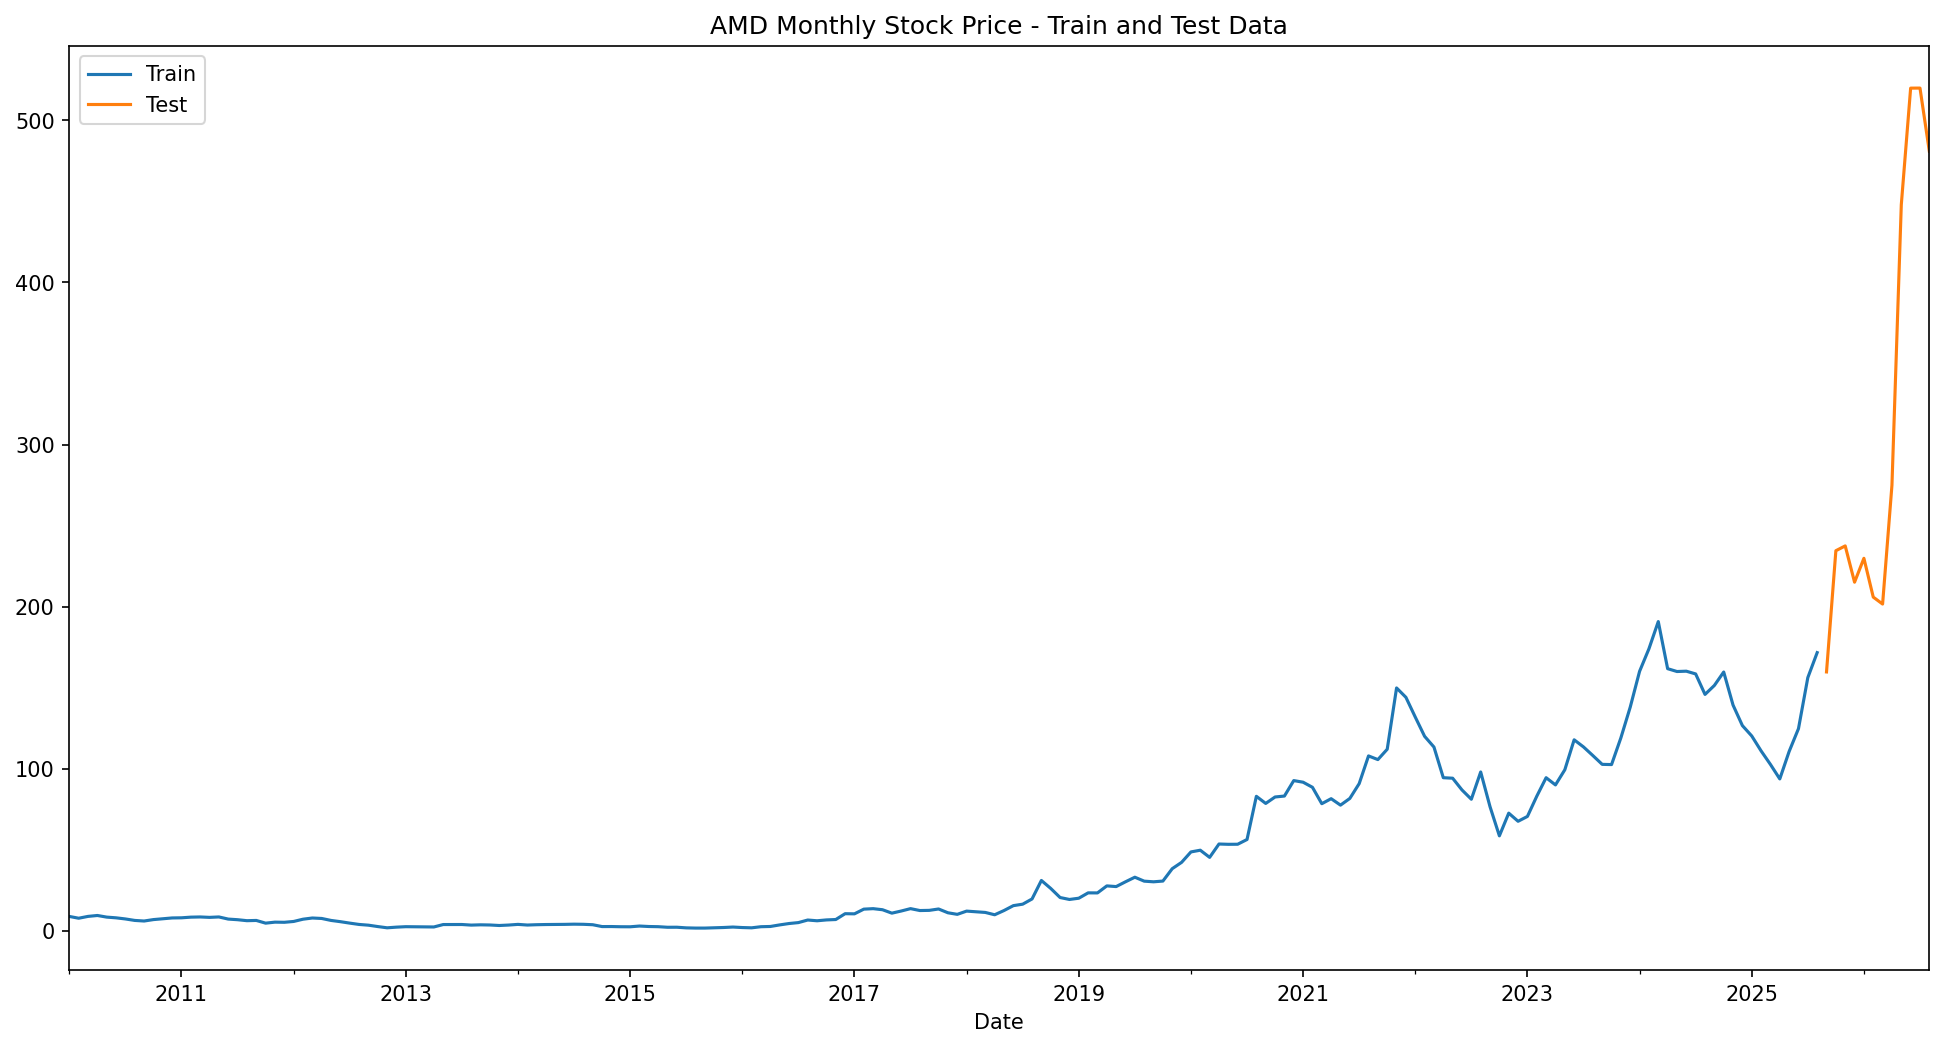

In [294]:
# Plot train and test data

# to set the plot size
plt.figure(figsize=(16, 8), dpi=150)

# plot training and testing data
train_data['AMD_Price'].plot(label='Train')
test_data['AMD_Price'].plot(label='Test')

# adding title to the plot
plt.title('AMD Monthly Stock Price - Train and Test Data')

# adding label to the x-axis
plt.xlabel('Date')

# adding legend to the curve
plt.legend()

plt.show()

### 3.2 Seasonal Decomposition

Before fitting the ETS models, I decompose the AMD training series into trend, seasonal, and residual components to examine its underlying time-series structure.

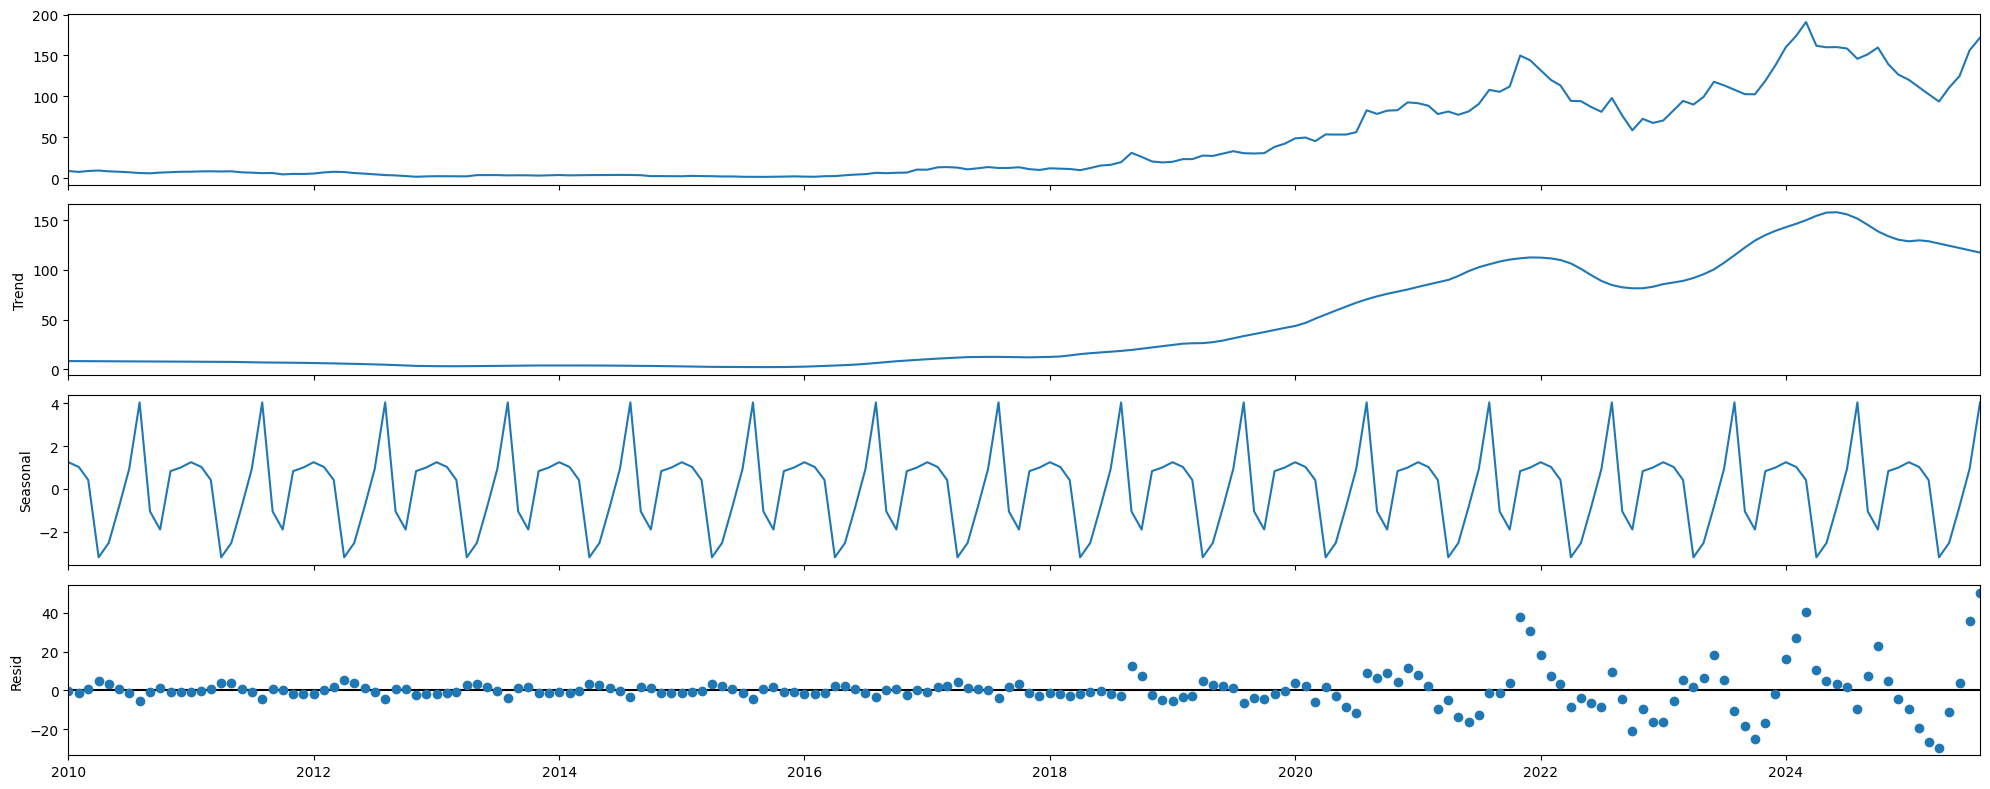

In [295]:
res = sm.tsa.seasonal_decompose(
    train_data,
    period=12,
    extrapolate_trend='period'
)

fig = res.plot()
fig.set_size_inches((20, 8))

# Tight layout to realign things
fig.tight_layout()

plt.show()

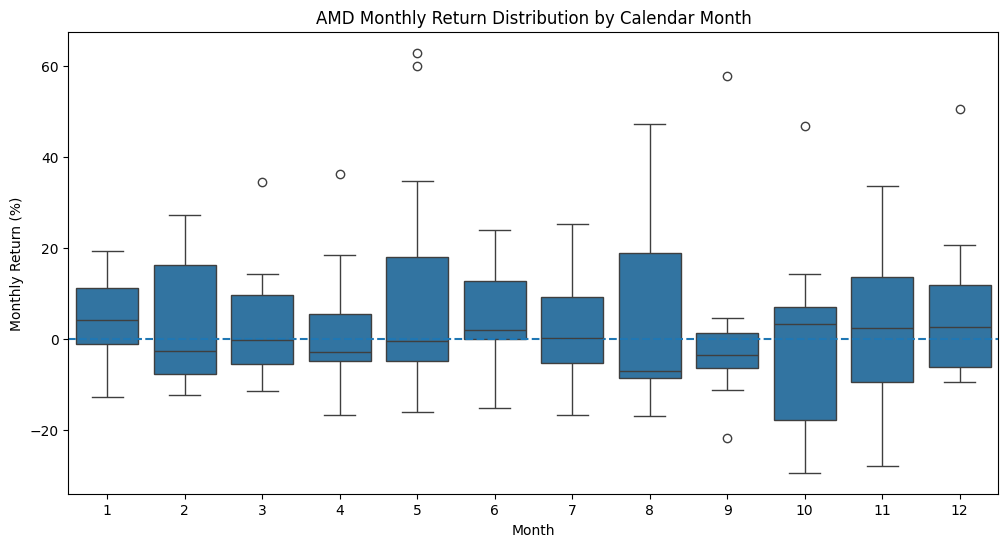

In [318]:
# distribution of AMD's monthly returns
amd_seasonality = amd_monthly.copy()

amd_seasonality['Monthly_Return'] = (
    amd_seasonality['AMD_Price'].pct_change() * 100
)

amd_seasonality['Month'] = amd_seasonality.index.month

plt.figure(figsize=(12, 6))

sns.boxplot(
    data=amd_seasonality.dropna(),
    x='Month',
    y='Monthly_Return'
)

plt.axhline(0, linestyle='--')
plt.title('AMD Monthly Return Distribution by Calendar Month')
plt.xlabel('Month')
plt.ylabel('Monthly Return (%)')

plt.show()

### 3.3 Simple Exponential Smoothing

Simple Exponential Smoothing (SES) is the simplest exponential smoothing method and is suitable for data without a clear trend or seasonal pattern.

Following the class example, three specifications are compared:

1. alpha = 0.2
2. alpha = 0.5
3. alpha automatically optimized by statsmodels

In [296]:
# First Instance
ins1 = SimpleExpSmoothing(
    train_data,
    initialization_method="estimated"
).fit(
    smoothing_level=0.2,
    optimized=False
)

ins_cast1 = ins1.forecast(12).rename('alpha=0.2')


# Second Instance
ins2 = SimpleExpSmoothing(
    train_data,
    initialization_method="estimated"
).fit(
    smoothing_level=0.5,
    optimized=False
)

ins_cast2 = ins2.forecast(12).rename('alpha=0.5')


# Third Instance
ins3 = SimpleExpSmoothing(
    train_data,
    initialization_method="estimated"
).fit()

ins_cast3 = ins3.forecast(12).rename(
    'alpha=%s' % ins3.model.params['smoothing_level']
)

In [297]:
ins_cast1

,alpha=0.2
2025-09-01,136.4002
2025-10-01,136.4002
2025-11-01,136.4002
2025-12-01,136.4002
2026-01-01,136.4002
2026-02-01,136.4002
2026-03-01,136.4002
2026-04-01,136.4002
2026-05-01,136.4002
2026-06-01,136.4002


In [298]:
test_data

,AMD_Price
Date,
2025-09-01,159.789993
2025-10-01,234.559998
2025-11-01,237.520004
2025-12-01,215.139999
2026-01-01,229.875000
2026-02-01,205.940002
2026-03-01,201.660004
2026-04-01,274.950012
2026-05-01,447.934998


The optimized smoothing parameter is approximately 1.0, indicating that the model places almost all weight on the most recent observation. I next compare the forecasts from the three Simple Exponential Smoothing specifications with the actual AMD prices in the test period.

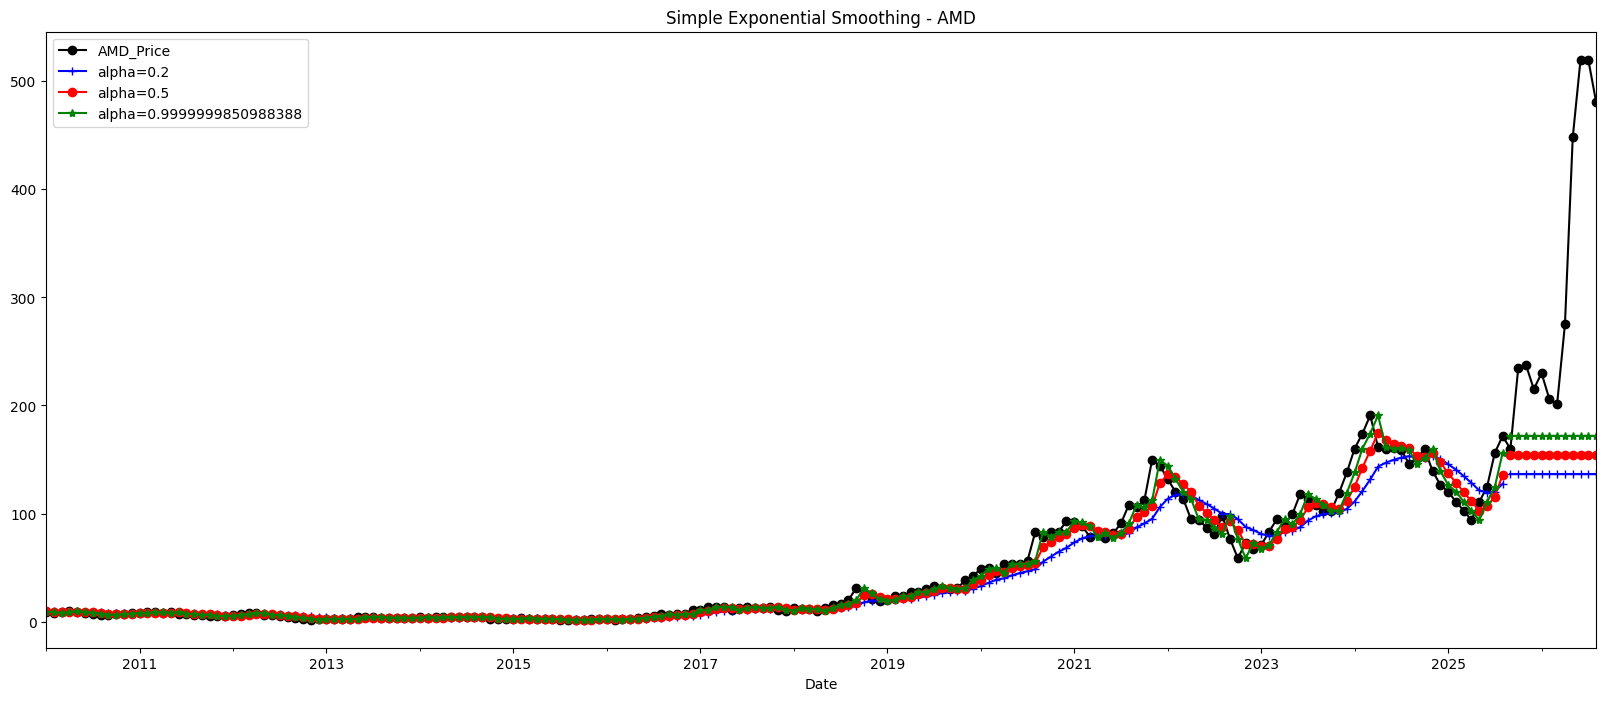

In [299]:
# After creating model we will visualize the plot
ax = amd.plot(
    marker='o',
    color='black',
    figsize=(20, 8),
    legend=True
)

# Plot for alpha = 0.2
ins_cast1.plot(
    marker='+',
    ax=ax,
    color='blue',
    legend=True
)

ins1.fittedvalues.plot(
    marker='+',
    ax=ax,
    color='blue'
)

# Plot for alpha = 0.5
ins_cast2.plot(
    marker='o',
    ax=ax,
    color='red',
    legend=True
)

ins2.fittedvalues.plot(
    marker='o',
    ax=ax,
    color='red'
)

# Plot for alpha = Optimized by statsmodels
ins_cast3.plot(
    marker='*',
    ax=ax,
    color='green',
    legend=True
)

ins3.fittedvalues.plot(
    marker='*',
    ax=ax,
    color='green'
)

plt.title('Simple Exponential Smoothing - AMD')
plt.show()

### 3.4 Double Exponential Smoothing

Double Exponential Smoothing extends Simple Exponential Smoothing by incorporating a trend component.

Both additive and multiplicative trend specifications are evaluated to determine whether AMD's price movements are better represented by approximately constant changes or proportional changes over time.

In [300]:
# Double ETS
# Fit the data on Double ES, using both Additive and Multiplicative Trend

double_ets_add = ExponentialSmoothing(
    train_data,
    trend='add'
).fit()

double_ets_mul = ExponentialSmoothing(
    train_data,
    trend='mul'
).fit()


double_ets_add_pred = double_ets_add.forecast(12)

double_ets_mul_pred = double_ets_mul.forecast(12)

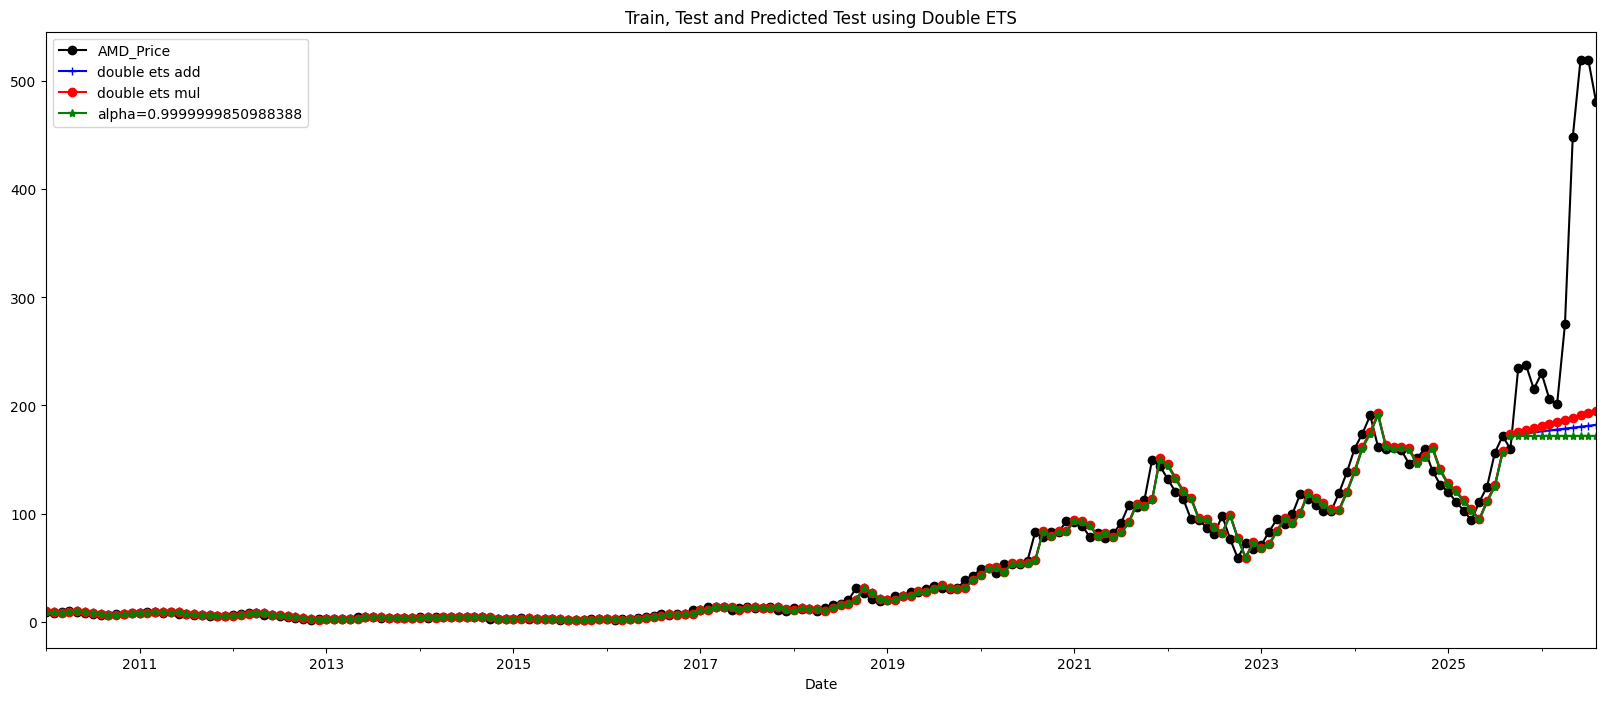

In [301]:
# Plot the train, test, and predictions

# Actual AMD series
ax = amd.plot(
    marker='o',
    color='black',
    figsize=(20, 8),
    legend=True
)

# Double ETS additive
double_ets_add_pred.plot(
    marker='+',
    ax=ax,
    color='blue',
    legend=True,
    label='double ets add'
)

double_ets_add.fittedvalues.plot(
    marker='+',
    ax=ax,
    color='blue'
)

# Double ETS multiplicative
double_ets_mul_pred.plot(
    marker='o',
    ax=ax,
    color='red',
    legend=True,
    label='double ets mul'
)

double_ets_mul.fittedvalues.plot(
    marker='o',
    ax=ax,
    color='red'
)

# Simple exponential smoothing - optimized alpha
ins_cast3.plot(
    marker='*',
    ax=ax,
    color='green',
    legend=True
)

ins3.fittedvalues.plot(
    marker='*',
    ax=ax,
    color='green'
)

plt.title('Train, Test and Predicted Test using Double ETS')
plt.show()

### 3.5 Triple Exponential Smoothing

Triple Exponential Smoothing extends exponential smoothing to incorporate both trend and seasonality.

Following the class example, additive and multiplicative Holt-Winters seasonal models are fitted. Since the AMD data are monthly, the seasonal period is set to 12.

In [302]:
# Triple ETS - Holt Winter's Seasonal Method

triple_ets_add = ExponentialSmoothing(
    train_data,
    trend='add',
    seasonal='add',
    seasonal_periods=12
).fit()

triple_ets_mul = ExponentialSmoothing(
    train_data,
    trend='mul',
    seasonal='mul',
    seasonal_periods=12
).fit()


triple_ets_add_pred = triple_ets_add.forecast(12)

triple_ets_mul_pred = triple_ets_mul.forecast(12)

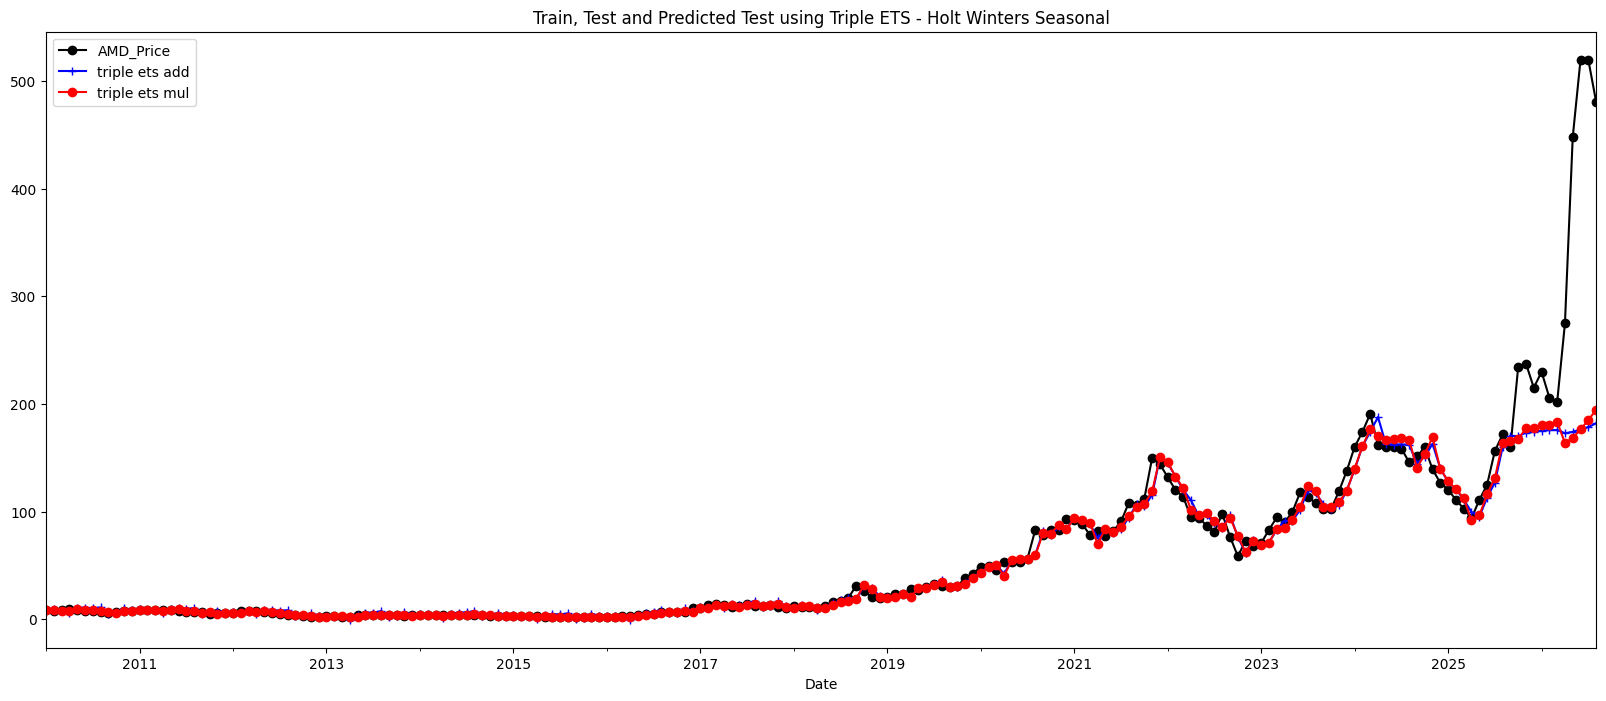

In [303]:
# Plot the train, test, and predictions

ax = amd.plot(
    marker='o',
    color='black',
    figsize=(20, 8),
    legend=True
)

# Triple ETS additive
triple_ets_add_pred.plot(
    marker='+',
    ax=ax,
    color='blue',
    legend=True,
    label='triple ets add'
)

triple_ets_add.fittedvalues.plot(
    marker='+',
    ax=ax,
    color='blue'
)

# Triple ETS multiplicative
triple_ets_mul_pred.plot(
    marker='o',
    ax=ax,
    color='red',
    legend=True,
    label='triple ets mul'
)

triple_ets_mul.fittedvalues.plot(
    marker='o',
    ax=ax,
    color='red'
)

plt.title(
    'Train, Test and Predicted Test using Triple ETS - Holt Winters Seasonal'
)

plt.show()

### 3.6 Residual Diagnostics

In [304]:
# Calculate residuals
residuals = [
    test_data.values.flatten()[i]
    - double_ets_mul_pred.values.flatten()[i]
    for i in range(len(test_data))
]

residuals = pd.DataFrame(residuals)

In [305]:
residuals

,0
0,-13.733477
1,59.193689
2,60.291285
3,36.029091
4,48.861914
5,23.004537
6,16.781743
7,88.108323
8,259.109029
9,329.018654


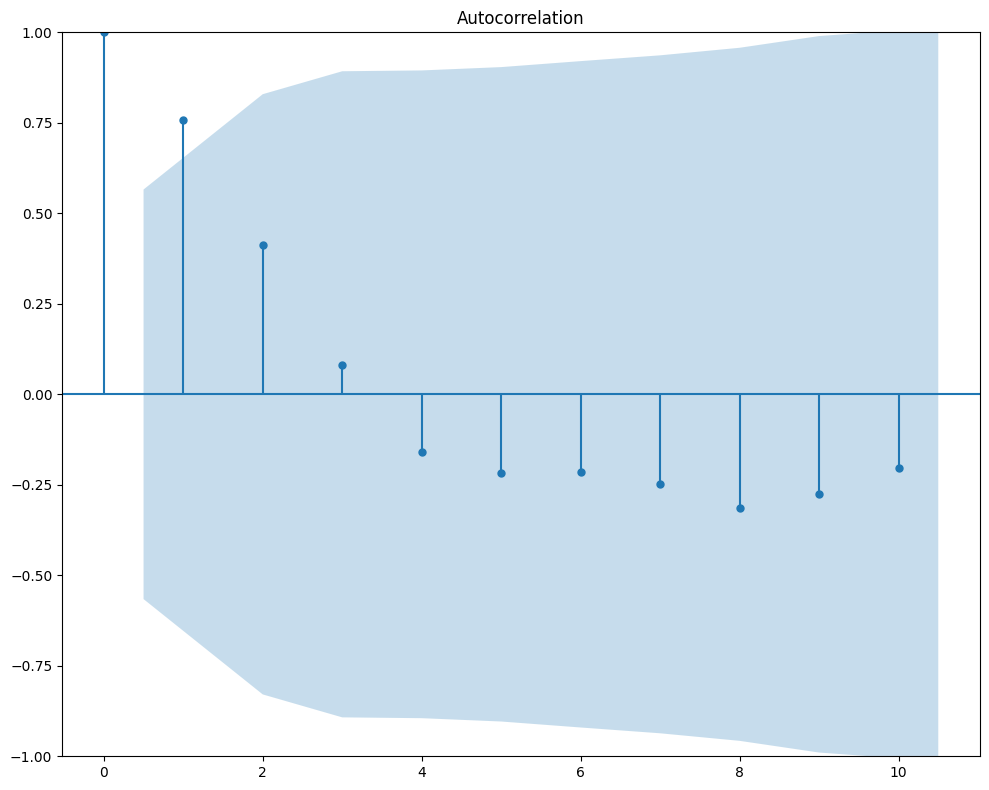

In [306]:
residuals_clean = residuals[0].dropna()

fig = plot_acf(
    residuals_clean,
    lags=min(10, len(residuals_clean) - 1)
)

fig.set_size_inches((10, 8))
fig.tight_layout()

plt.show()

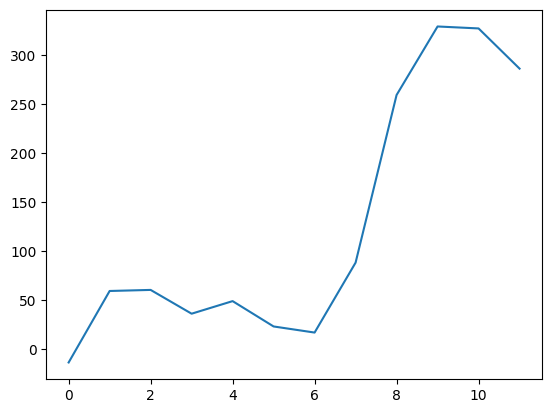

In [307]:
# Plot residuals
residuals_clean.plot()

plt.show()

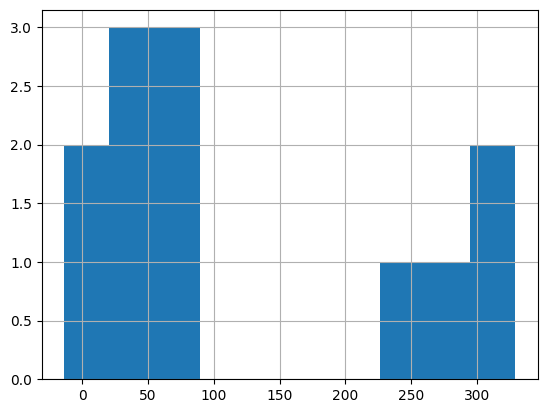

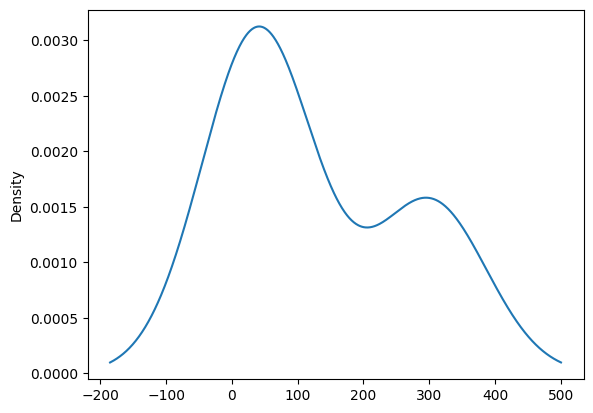

In [308]:
# Histogram plot
residuals_clean.hist()
plt.show()

# Density plot
residuals_clean.plot(kind='kde')
plt.show()

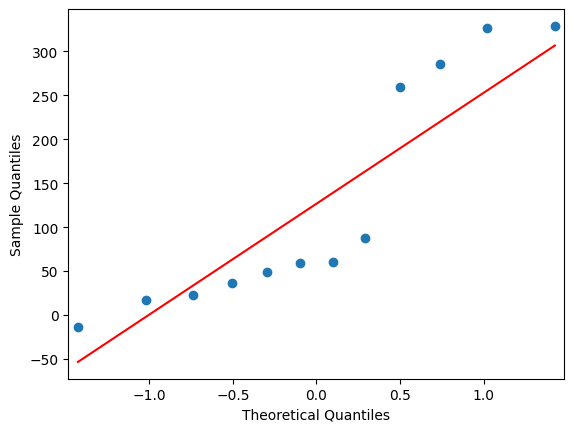

In [309]:
qqplot(residuals_clean, line='s')
plt.show()

### 3.7 Metrics - model evaluation

1. Root Mean Squared Error (RMSE) represents the sample standard deviation of the differences between predicted values and observed values. These individual differences are called residuals when the calculations are performed over the data sample that was used for estimation, and are called prediction errors when computed out-of-sample. This is a great measurement to use when comparing models as it shows how many deviations from the mean the forecasted values fall.
2. Mean Absolute Error (MAE) takes the sum of the absolute difference from actual to forecast and averages them. It is less sensitive to the occasional very large error because it does not square the errors in the calculation.
3. Mean Absolute Percentage Error (MAPE) is also often useful for purposes of reporting, because it is expressed in generic percentage terms it will make sense even to someone who has no idea what constitutes a "big" error in terms of dollars spent or widgets sold.


In [310]:
# Define metrics dataframe which will be used below for storing results

metrics_dataframe = pd.DataFrame(
    columns=['Model', 'RMSE', 'MAE', 'MAPE']
)


def metrics_cal(actuals, predictions, model):

    mse = mean_squared_error(actuals, predictions)

    rmse = sqrt(mse)

    mae = mean_absolute_error(actuals, predictions)

    mape = np.mean(
        np.abs((actuals - predictions) / actuals)
    ) * 100


    df = pd.DataFrame({
        'Model': [model],
        'RMSE': [rmse],
        'MAE': [mae],
        'MAPE': [mape]
    })


    global metrics_dataframe

    metrics_dataframe = pd.concat(
        [metrics_dataframe, df],
        ignore_index=True
    )

    return metrics_dataframe

In [311]:
# Get all the metrics

metrics_dataframe = metrics_cal(
    test_data.values.flatten(),
    ins_cast1.values.flatten(),
    'Simple 0.2'
)

metrics_dataframe = metrics_cal(
    test_data.values.flatten(),
    ins_cast2.values.flatten(),
    'Simple 0.5'
)

metrics_dataframe = metrics_cal(
    test_data.values.flatten(),
    ins_cast3.values.flatten(),
    'Simple Optimized'
)

metrics_dataframe = metrics_cal(
    test_data.values.flatten(),
    double_ets_add_pred.values.flatten(),
    'Double Add'
)

metrics_dataframe = metrics_cal(
    test_data.values.flatten(),
    double_ets_mul_pred.values.flatten(),
    'Double Mul'
)

metrics_dataframe = metrics_cal(
    test_data.values.flatten(),
    triple_ets_add_pred.values.flatten(),
    'Triple Add'
)

metrics_dataframe = metrics_cal(
    test_data.values.flatten(),
    triple_ets_mul_pred.values.flatten(),
    'Triple Mul'
)

/tmp/ipykernel_864/2866985125.py:31: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  metrics_dataframe = pd.concat(


In [312]:
metrics_dataframe.sort_values(by='MAE')

,Model,RMSE,MAE,MAPE
4,Double Mul,178.823498,128.931885,32.688977
6,Triple Mul,186.079240,134.878401,34.209163
3,Double Add,185.802771,135.443907,34.673478
5,Triple Add,187.921550,137.526691,35.293710
2,Simple 1,191.658896,140.954586,36.367460
1,Simple 0.5,204.964668,156.811761,41.866657
0,Simple 0.2,218.610165,174.269383,48.462811


### 3.8 Additional 2 Accuracy Metrics

In addition to RMSE, MAE, and MAPE, I use two additional forecast accuracy metrics: Symmetric Mean Absolute Percentage Error (sMAPE) and Mean Absolute Scaled Error (MASE).

**sMAPE** is a scale-independent percentage-based measure similar to MAPE, but it treats the actual and forecast values more symmetrically. This is useful because it reduces some of the asymmetry associated with conventional percentage errors.

**MASE** compares the model's absolute forecast error with the error from a naïve one-step forecast. This is particularly useful for stock-price forecasting because it indicates whether an ETS model actually improves upon a simple forecast that assumes the next month's price will be similar to the previous month's price.

For both sMAPE and MASE, lower values indicate better forecast accuracy. A MASE value below 1 indicates that the model performs better than the naïve benchmark.

In [313]:
# sMAPE
def smape(actuals, predictions):

    actuals = np.array(actuals)
    predictions = np.array(predictions)

    return np.mean(
        2 * np.abs(actuals - predictions) /
        (np.abs(actuals) + np.abs(predictions))
    ) * 100

In [314]:
# MASE
def mase(actuals, predictions, training_data):

    actuals = np.array(actuals)
    predictions = np.array(predictions)
    training_data = np.array(training_data)

    # MAE of naive one-step forecast on training data
    naive_mae = np.mean(
        np.abs(training_data[1:] - training_data[:-1])
    )

    # MAE of ETS forecast
    model_mae = np.mean(
        np.abs(actuals - predictions)
    )

    return model_mae / naive_mae

In [315]:
models_predictions = {
    'Simple 0.2': ins_cast1.values.flatten(),
    'Simple 0.5': ins_cast2.values.flatten(),
    'Simple Optimized': ins_cast3.values.flatten(),
    'Double Add': double_ets_add_pred.values.flatten(),
    'Double Mul': double_ets_mul_pred.values.flatten(),
    'Triple Add': triple_ets_add_pred.values.flatten(),
    'Triple Mul': triple_ets_mul_pred.values.flatten()
}

In [316]:
actual_values = test_data.values.flatten()
training_values = train_data.values.flatten()

additional_metrics = []

for model, predictions in models_predictions.items():

    model_smape = smape(
        actual_values,
        predictions
    )

    model_mase = mase(
        actual_values,
        predictions,
        training_values
    )

    additional_metrics.append({
        'Model': model,
        'sMAPE': model_smape,
        'MASE': model_mase
    })

additional_metrics_df = pd.DataFrame(additional_metrics)

additional_metrics_df

,Model,sMAPE,MASE
0,Simple 0.2,68.101005,40.799219
1,Simple 0.5,57.611155,36.712114
2,Simple 1,48.954288,32.999698
3,Double Add,46.229149,31.709561
4,Double Mul,43.109464,30.184994
5,Triple Add,47.265263,32.197174
6,Triple Mul,45.944388,31.577167


In [317]:
final_metrics = pd.merge(
    metrics_dataframe,
    additional_metrics_df,
    on='Model'
)

final_metrics

,Model,RMSE,MAE,MAPE,sMAPE,MASE
0,Simple 0.2,218.610165,174.269383,48.462811,68.101005,40.799219
1,Simple 0.5,204.964668,156.811761,41.866657,57.611155,36.712114
2,Simple 1,191.658896,140.954586,36.367460,48.954288,32.999698
3,Double Add,185.802771,135.443907,34.673478,46.229149,31.709561
4,Double Mul,178.823498,128.931885,32.688977,43.109464,30.184994
5,Triple Add,187.921550,137.526691,35.293710,47.265263,32.197174
6,Triple Mul,186.079240,134.878401,34.209163,45.944388,31.577167


### 3.9 Model Comparison

Among the seven ETS specifications, the Double Exponential Smoothing model with a multiplicative trend produces the lowest values across all five accuracy metrics.

Its RMSE is approximately 178.82, MAE is 128.93, MAPE is 32.69%, sMAPE is 43.11%, and MASE is 30.18. The Triple Exponential Smoothing model with multiplicative trend and multiplicative seasonality is the next strongest model, although its forecast errors are slightly higher.

The results show that incorporating a trend improves forecasting performance substantially compared with Simple Exponential Smoothing. The multiplicative trend specification performs particularly well, suggesting that changes in AMD's stock price may be better represented proportionally as the overall price level increases.

Adding a seasonal component does not improve forecasting accuracy in this test period. Therefore, the Double Multiplicative ETS model provides the best forecast among the ETS models tested.

However, the relatively large forecast errors indicate that even the best ETS model has difficulty capturing the unusually large movements in AMD's stock price during the test period.

### 3.10 Final Forecasting Discussion

Seven ETS specifications were evaluated to forecast AMD's monthly stock price, including three Simple Exponential Smoothing models, two Double Exponential Smoothing models, and two Triple Exponential Smoothing models. Model performance was compared using RMSE, MAE, MAPE, sMAPE, and MASE.

In addition to the required RMSE, MAE, and MAPE, I selected sMAPE and MASE as two additional accuracy metrics. sMAPE expresses forecast error in percentage terms while treating actual and predicted values more symmetrically than MAPE. MASE scales the model's absolute forecast error relative to the average one-step naïve forecast error in the training data.

Among all seven models, the Double Exponential Smoothing model with a multiplicative trend performed best across all five metrics. It produced an RMSE of approximately 178.82, MAE of 128.93, MAPE of 32.69%, sMAPE of 43.11%, and MASE of 30.18.

The results suggest that incorporating a trend improves forecasting performance compared with Simple Exponential Smoothing. The multiplicative trend specification performs better than the additive trend specification, which may reflect the fact that AMD's price movements tend to become larger as the overall price level increases.

Adding seasonality through Triple Exponential Smoothing does not improve forecast accuracy relative to the Double Multiplicative model. This suggests that a seasonal component provides limited additional predictive value for AMD over the selected sample.

However, even the best model produces relatively large forecast errors. AMD experienced substantial price increases during the test period that the ETS models were unable to fully capture. Therefore, Double Multiplicative ETS is the best model among those tested, but its forecasting accuracy remains limited during large and unexpected stock-price movements.